<a href="https://colab.research.google.com/github/Nicossm/devsal-ml/blob/main/04_hyperparameter_optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04 - Hyperparameter Optimization

## Contexto

En esta etapa se optimizan los hiperparámetros de los modelos de clustering implementados previamente.

Para K-Means se evalúan distintos valores de K.

Para Agglomerative Clustering se comparan distintos métodos de linkage.

La optimización se realiza utilizando silhouette score como métrica principal.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering

from sklearn.metrics import silhouette_score

## Carga de datos

Se utiliza el dataset previamente procesado durante la etapa ETL del proyecto.

El dataset contiene información sobre experiencia, tecnologías utilizadas, educación, tamaño de empresa y salarios de desarrolladores.

In [ ]:
url = "https://raw.githubusercontent.com/Nicossm/devsal-ml/main/etl/data/processed/clean.csv"
df = pd.read_csv(url)
df.head()

,experience,country,education,languages,frameworks,company_size,salary_usd,num_languages,num_frameworks,salary_usd_before_cap
0,24,India,Bachelors,"Go, Ruby","Django, Flask",5000+,122189.0,2,2,122189.0
1,38,France,Masters,"Python, Ruby",Unknown,201-1000,147754.0,2,1,147754.0
2,36,USA,Some College,"C++, PHP","Ruby on Rails, Spring",5000+,220819.0,2,2,220819.0
3,3,India,Masters,"Java, JavaScript","Ruby on Rails, Spring",1-10,31943.0,2,2,31943.0
4,18,USA,Masters,"Go, Java","Django, React",5000+,166442.0,2,2,166442.0


## Selección de variables

Para el clustering se utilizarán únicamente variables descriptivas del perfil del desarrollador:

- `experience`
- `num_languages`
- `num_frameworks`
- `country`
- `education`
- `company_size`

La variable `salary_usd` fue excluida deliberadamente para evitar que los clusters queden definidos directamente por salario.

A diferencia de los modelos supervisados, el clustering no utiliza una variable objetivo.

In [ ]:
features = [
    "experience",
    "num_languages",
    "num_frameworks",
    "country",
    "education",
    "company_size"
]

X = df[features]

In [ ]:
numeric_features = [
    "experience",
    "num_languages",
    "num_frameworks"
]

categorical_features = [
    "country",
    "education",
    "company_size"
]

## Preprocesamiento

El clustering mediante K-Means utiliza distancia euclidiana, por lo que las diferencias de escala entre variables pueden afectar significativamente los resultados.

Por esta razón:

- Las variables numéricas se escalan utilizando `StandardScaler`.
- Las variables categóricas se transforman mediante `OneHotEncoder`.

El preprocesamiento se implementa utilizando `ColumnTransformer` para mantener una estructura modular y reproducible.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

In [ ]:
X_processed = preprocessor.fit_transform(X)

In [ ]:
X_processed.shape

(9249, 25)

Los datos quedaron correctamente transformados y preparados para el entrenamiento de modelos de clustering.

## Optimización de K-Means

In [ ]:
results_kmeans = []

K_range = range(2, 11)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_processed)

    silhouette = silhouette_score(
        X_processed,
        labels
    )

    results_kmeans.append({
        "K": k,
        "silhouette_score": silhouette,
        "inertia": kmeans.inertia_
    })

## Método del codo

El método del codo permite analizar cómo disminuye la inercia (`inertia`) a medida que aumenta la cantidad de clusters.

El objetivo es identificar el punto donde la reducción del error comienza a estabilizarse.

In [ ]:
inertias = []

K_range = range(2, 11)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_processed)

    inertias.append(kmeans.inertia_)

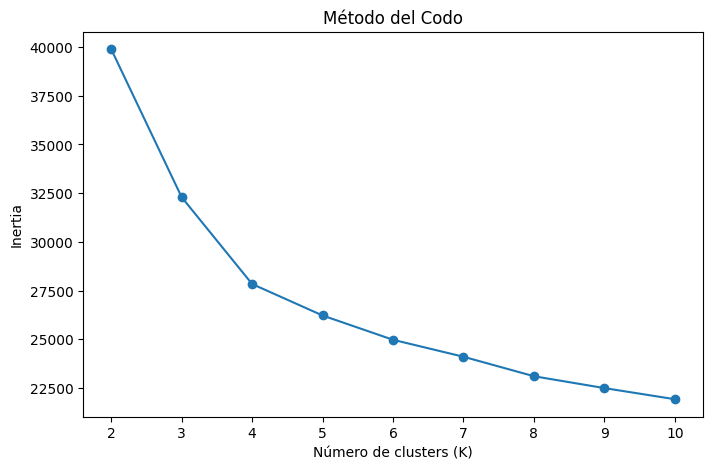

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(K_range, inertias, marker='o')

plt.xlabel("Número de clusters (K)")
plt.ylabel("Inertia")
plt.title("Método del Codo")

plt.show()

El gráfico permite observar una reducción importante de la inercia en los primeros valores de K.

A partir de cierto punto, la mejora comienza a disminuir progresivamente, indicando una posible cantidad adecuada de clusters.

## Silhouette Score

El silhouette score permite medir qué tan bien separados y compactos se encuentran los clusters.

Valores más altos indican una mejor separación entre grupos.

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_processed)

    score = silhouette_score(X_processed, labels)

    silhouette_scores.append(score)

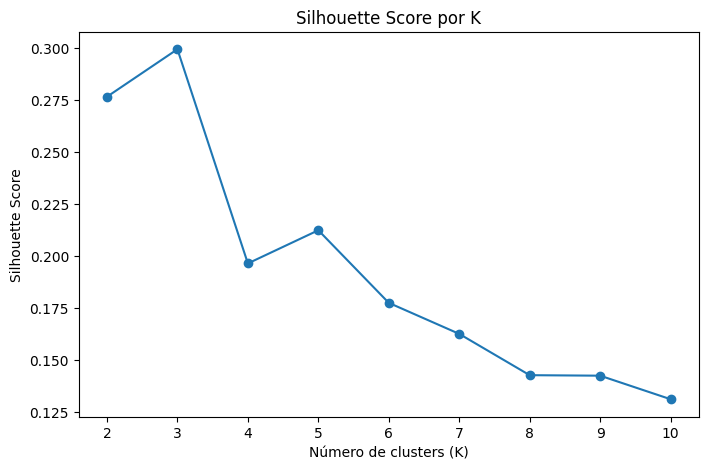

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(K_range, silhouette_scores, marker='o')

plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score por K")

plt.show()

Considerando el método del codo y el comportamiento del silhouette score, se seleccionó `K=4` como balance adecuado entre separación y compactación de clusters.

## Optimización de Agglomerative Clustering

In [ ]:
linkages = [
    "ward",
    "complete",
    "average"
]

agg_results = []

for linkage in linkages:

    agg = AgglomerativeClustering(
        n_clusters=4,
        linkage=linkage
    )

    labels = agg.fit_predict(
        X_processed.toarray()
    )

    score = silhouette_score(
        X_processed.toarray(),
        labels
    )

    agg_results.append({
        "linkage": linkage,
        "silhouette_score": score
    })

In [ ]:
agg_results_df = pd.DataFrame(agg_results)

agg_results_df

,linkage,silhouette_score
0,ward,0.172392
1,complete,0.161185
2,average,0.313810


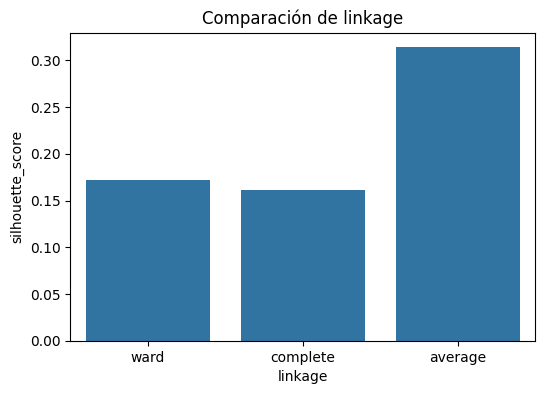

In [ ]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=agg_results_df,
    x="linkage",
    y="silhouette_score"
)

plt.title("Comparación de linkage")

plt.show()

Los distintos métodos de linkage generan diferencias en la forma en que se agrupan los perfiles.

Algunas configuraciones producen clusters más compactos y mejor separados según silhouette score.

In [ ]:
best_k = kmeans_results_df.sort_values(
    "silhouette_score",
    ascending=False
).iloc[0]

best_linkage = agg_results_df.sort_values(
    "silhouette_score",
    ascending=False
).iloc[0]

print(best_k)
print(best_linkage)

K                       3.000000
silhouette_score        0.299597
inertia             32292.567833
Name: 1, dtype: float64
linkage             average
silhouette_score    0.31381
Name: 2, dtype: object


# Conclusiones

La optimización permitió identificar configuraciones más adecuadas para los modelos de clustering.

K-Means presentó mejor desempeño general utilizando el valor óptimo de K seleccionado durante el análisis.

En Agglomerative Clustering, algunos métodos de linkage mostraron mejor separación entre grupos que otros.

La etapa de optimización permitió validar y fortalecer los resultados obtenidos previamente en la fase de modelado.